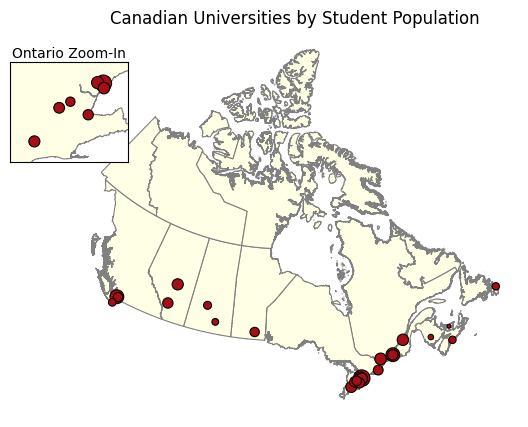

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium

canada = gpd.read_file("canada.shp")
universities = gpd.read_file("universities.geojson")

# Reproject universities to match Canada's CRS
universities = universities.to_crs(canada.crs).copy()

# Clean student column and remove missing values
universities["Total students"] = pd.to_numeric(universities["Total students"], errors="coerce")
universities = universities.dropna(subset=["Total students"]).copy()

# Select the 7 Southern Ontario universities for the inset
ontario_names = [
    "University of Toronto",
    "Toronto Metropolitan University",
    "York University",
    "University of Waterloo",
    "University of Guelph",
    "McMaster University",
    "University of Western Ontario"
]
ontario_zoom = universities[universities["Institution"].isin(ontario_names)].copy()

# Scale point sizes by total students
universities["plot_size"] = universities["Total students"] / 700
ontario_zoom["plot_size"] = ontario_zoom["Total students"] / 700

# Create figure and main map
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

canada.plot(
    ax=ax,
    color="#FFFFE5",
    edgecolor="gray",
    linewidth=0.8
)

universities.plot(
    ax=ax,
    color="#A50F15",
    edgecolor="black",
    linewidth=0.8,
    markersize=universities["plot_size"]
)

ax.set_title(
    "Canadian Universities by Student Population",
    fontsize=12,
    fontweight="normal"
)
ax.set_axis_off()

# Create inset for Southern Ontario
ax_inset = fig.add_axes([0.12, 0.62, 0.22, 0.20])

canada.plot(
    ax=ax_inset,
    color="#FFFFE5",
    edgecolor="gray",
    linewidth=0.8
)

ontario_zoom.plot(
    ax=ax_inset,
    color="#A50F15",
    edgecolor="black",
    linewidth=0.8,
    markersize=ontario_zoom["plot_size"]
)

# Zoom inset to Southern Ontario universities
minx, miny, maxx, maxy = ontario_zoom.total_bounds
pad_x = (maxx - minx) * 0.35
pad_y = (maxy - miny) * 0.35
ax_inset.set_xlim(minx - pad_x, maxx + pad_x)
ax_inset.set_ylim(miny - pad_y, maxy + pad_y)

ax_inset.set_title(
    "Ontario Zoom-In",
    fontsize=10,
    pad=3,
    fontweight="normal"
)

ax_inset.set_xticks([])
ax_inset.set_yticks([])

# Show inset border
for spine in ax_inset.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("black")

plt.show()

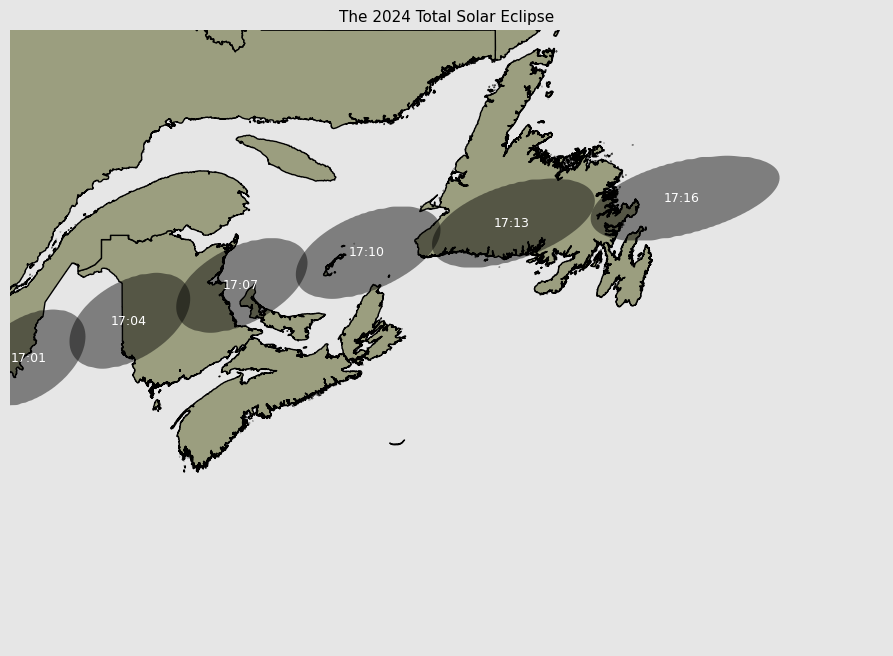

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Load datasets
canada = gpd.read_file("canada.shp")
umbra = gpd.read_file("umbra_lo.shp")

# Reproject Canada to match the umbra CRS
canada = canada.to_crs(umbra.crs).copy()

# Convert UTC to Newfoundland local time
umbra["utc_dt"] = pd.to_datetime(umbra["UTCTime"], format="%H:%M:%S", errors="coerce")
umbra["local_dt"] = umbra["utc_dt"] - pd.Timedelta(hours=2, minutes=30)
umbra["local_time"] = umbra["local_dt"].dt.strftime("%H:%M:%S")
umbra["label"] = umbra["local_dt"].dt.strftime("%H:%M")

# Keep the six shadows shown in the reference image
target_local_times = ["17:01:00", "17:04:00", "17:07:00", "17:10:00", "17:13:00", "17:16:00"]
eclipse = umbra[umbra["local_time"].isin(target_local_times)].copy()

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("#E6E6E6")
ax.set_facecolor("#E6E6E6")

# Plot Canada
canada.plot(
    ax=ax,
    color="#9B9E7F",
    edgecolor="black",
    linewidth=1
)

# Plot eclipse shadows
eclipse.plot(
    ax=ax,
    color="black",
    alpha=0.45,
    edgecolor="none"
)

# Add labels at the shadow centers
for _, row in eclipse.iterrows():
    ax.text(
        row["CenterLon"],
        row["CenterLat"],
        row["label"],
        color="white",
        fontsize=9,
        ha="center",
        va="center"
    )

# Tighter zoom to better match the reference image
ax.set_xlim(-71, -46.0)
ax.set_ylim(40, 52)

ax.set_title("The 2024 Total Solar Eclipse", fontsize=11, fontweight="normal")
ax.set_axis_off()

plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import folium

# Load eclipse data
umbra = gpd.read_file("umbra_lo.shp")

# Convert UTC to Newfoundland local time
umbra["utc_dt"] = pd.to_datetime(umbra["UTCTime"], format="%H:%M:%S", errors="coerce")
umbra["local_dt"] = umbra["utc_dt"] - pd.Timedelta(hours=2, minutes=30)
umbra["local_time"] = umbra["local_dt"].dt.strftime("%H:%M:%S")
umbra["label"] = umbra["local_dt"].dt.strftime("%H:%M")

# Keep the same six eclipse shadows
target_local_times = ["17:01:00", "17:04:00", "17:07:00", "17:10:00", "17:13:00", "17:16:00"]
eclipse = umbra[umbra["local_time"].isin(target_local_times)].copy()

# Folium uses EPSG:4326
eclipse = eclipse.to_crs(epsg=4326)

# Create map with ESRI as the base map
m = folium.Map(
    location=[47.2, -58.8],
    zoom_start=5,
    tiles=None,
    width="100%",
    height=635
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri — Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community",
    name="ESRI WorldTopoMap",
    overlay=False,
    control=False
).add_to(m)

# Add eclipse shadows
for _, row in eclipse.iterrows():
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda feature: {
            "fillColor": "gray",
            "color": "gray",
            "weight": 1,
            "fillOpacity": 0.22
        },
        tooltip=row["label"]
    ).add_to(m)

# Bounds tuned to look closer to the reference image
m.fit_bounds([[44.4, -72.9], [49.6, -49.9]])
m